In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Libraries imported successfully.")



Libraries imported successfully.


In [64]:
df = pd.read_csv('house_price_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100, 8)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


In [65]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
count,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,100.000000,100.000000
mean,2717.380000,2.980000,2.040000,21.440000,14.676289,0.420000,1.890000,328377.300000
std,1104.021197,1.476961,0.839913,11.001671,8.517332,0.496045,0.827495,134402.974694
min,621.000000,1.000000,1.000000,0.000000,1.400000,0.000000,1.000000,55418.000000
25%,1807.250000,1.750000,1.000000,14.000000,6.700000,0.000000,1.000000,210127.250000
50%,2791.500000,3.000000,2.000000,22.500000,14.800000,0.000000,2.000000,332383.500000
75%,3622.000000,4.000000,3.000000,31.000000,21.400000,1.000000,3.000000,439099.250000
max,4493.000000,5.000000,3.000000,39.000000,29.700000,1.000000,3.000000,578851.000000


In [66]:
df.fillna(df.mean(), inplace=True)
print('missing values in sum:')
print(df.isnull().sum())

missing values in sum:
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    0
Garage                 0
Floors                 0
Price_USD              0
dtype: int64


In [67]:
df.fillna(df.mean(), inplace=True)
print('missing values after filling in sum:')
print(df.isnull().sum().sum())

missing values after filling in sum:
0


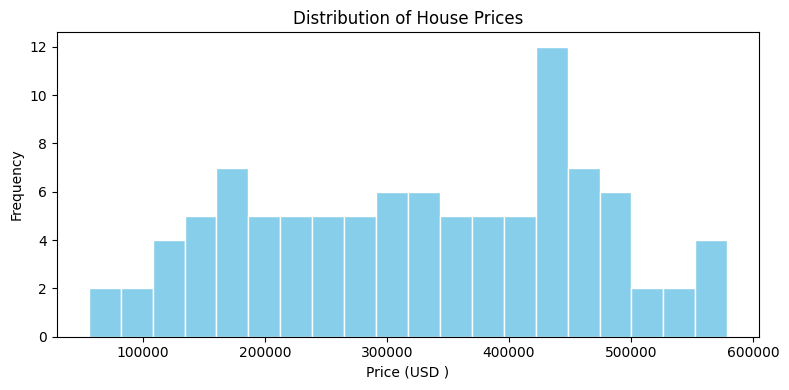

In [68]:
plt.figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, edgecolor='white', color='skyblue')
plt.xlabel('Price (USD )')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.tight_layout()
plt.show()

In [69]:
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
X = df[features]
y = df['Price_USD']
print(f'Features: {features}')
print(f'x shape: {x.shape}, y shape: {y.shape}')

Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
x shape: (100, 7), y shape: (100,)


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 80
Testing samples  : 20


In [71]:
train_mean = X_train.mean()
test_mean = X_test.mean()
X_train = X_train.fillna(train_mean)
X_test= X_test.fillna(test_mean)
print('X_train_null : ', X_train.isnull().sum().sum())
print('X_test_null : ', X_test.isnull().sum().sum())

X_train_null :  0
X_test_null :  0


In [72]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('feature scaled using standardscaler')

feature scaled using standardscaler


Train the model

In [73]:
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model trained!')
print(f'\nIntercept : {model.intercept_:,.2f}')

coef_df = pd.DataFrame({'Feature': features,            'Coefficient': model.coef_})
print('\nCoefficients:')
print(coef_df.to_string(index=False))

✅ Model trained!

Intercept : 333,429.67

Coefficients:
            Feature   Coefficient
          Area_sqft 128249.834226
           Bedrooms  22800.577570
          Bathrooms  10436.304349
          Age_years -26528.165385
Distance_to_city_km -27821.936315
             Garage   9719.024704
             Floors   7538.042419


Evaluate the model

In [74]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : ${mae:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'R²   : {r2:.4f}')
print(f'\n📌 R² of {r2:.2f} means the model explains {r2*100:.1f}% of the variance in house prices.')

MAE  : $16,392.59
RMSE : $21,081.70
R²   : 0.9789

📌 R² of 0.98 means the model explains 97.9% of the variance in house prices.


New data prediction

In [76]:
new_houses = pd.DataFrame({
    'Area_sqft'           : [1500, 3000],
    'Bedrooms'            : [2,    4   ],
    'Bathrooms'           : [1,    3   ],
    'Age_years'           : [10,   5   ],
    'Distance_to_city_km' : [15,   8   ],
    'Garage'              : [0,    1   ],
    'Floors'              : [1,    2   ]
})

# Fill any missing using training mean, then scale
new_houses_filled = new_houses.fillna(train_mean)
new_scaled        = scaler.transform(new_houses_filled)

predictions = model.predict(new_scaled).astype(int)
new_houses['Predicted_Price_USD'] = predictions

print('🏡 Predicted Prices:')
print(new_houses.to_string(index=False))

🏡 Predicted Prices:
 Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_city_km  Garage  Floors  Predicted_Price_USD
      1500         2          1         10                   15       0       1               164593
      3000         4          3          5                    8       1       2               464053
